## Setup

In [2]:
import sys, json, asyncio, os

# ── Phải set path TRƯỚC load_dotenv để config.py resolve đúng ──
sys.path.append("D:/KLTN/Project/BE_ChatBot")

from dotenv import load_dotenv

load_dotenv()

from config import *
from metrics import precision_at_k, ndcg_at_k, average_metrics

print(PERSIST_DIRECTORY)
print(os.path.exists(PERSIST_DIRECTORY))

D:\KLTN\Project\BE_ChatBot\src\db\chroma_db
True


##  Load ChromaDB & Retrievers

In [3]:
import os
from langchain_chroma import Chroma
from src.core.base_embed_model import get_embedding_model
from src.pipeline.rag_pipline import RAGStorage

# ── Override để RAGStorage dùng đúng absolute path ──
os.environ["PERSIST_DIRECTORY"] = PERSIST_DIRECTORY  # PERSIST_DIRECTORY đã được resolve đúng từ config.py

embedding_model = get_embedding_model()

vectorstore = Chroma(
    persist_directory=PERSIST_DIRECTORY,
    embedding_function=embedding_model,
    collection_name=COLLECTION_NAME,
)

print(f"✅ ChromaDB loaded: {len(vectorstore.get()['ids'])} chunks")

storage = RAGStorage()
base_retriever       = storage.get_retriever()
multiquery_retriever = storage.get_multi_query_retriever()


📁 Cache dir embedding model: D:\KLTN\Project\BE_ChatBot\src\model\embeddings 

🔧 Provider : huggingface
🔧 Model    : AITeamVN/Vietnamese_Embedding
🔧 Device   : cuda
🔧 Cache    : D:\KLTN\Project\BE_ChatBot\src\model\embeddings


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅ ChromaDB loaded: 1387 chunks

- Chạy embedding model bằng: 'cuda' 

🔧 Provider : huggingface
🔧 Model    : AITeamVN/Vietnamese_Embedding
🔧 Device   : cuda
🔧 Cache    : D:\KLTN\Project\BE_ChatBot\src\model\embeddings


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


- Tải CSDL Chroma từ thư mục: D:\KLTN\Project\BE_ChatBot\src\db\chroma_db

- Tải CSDL Chroma từ thư mục: D:\KLTN\Project\BE_ChatBot\src\db\chroma_db

🚀 Initializing LLM [LLMProvider.GROQ / default] 

🔧 Provider : groq
🔧 Model    : llama-3.1-8b-instant

- LLM cho multi query


## Tạo ground truth - run once

In [3]:
# Chỉ chạy cell này 1 lần để tạo file ground_truth.json
# Sau này thay data du lịch → chạy lại cell này, mọi thứ khác giữ nguyên
from ground_truth_builder import build_ground_truth

print(GROUND_TRUTH_PATH)
dataset = build_ground_truth(n_queries=20, delay_seconds=1.5, output_path=GROUND_TRUTH_PATH)

eval/ground_truth.json

🚀 Initializing LLM [LLMProvider.GROQ / default] 

🔧 Provider : groq
🔧 Model    : llama-3.1-8b-instant

🚀 Initializing LLM [LLMProvider.GROQ / default] 

🔧 Provider : groq
🔧 Model    : llama-3.1-8b-instant
🔌 Kết nối ChromaDB...
🔧 Provider : huggingface
🔧 Model    : AITeamVN/Vietnamese_Embedding
🔧 Device   : cuda
🔧 Cache    : D:\KLTN\Project\BE_ChatBot\src\model\embeddings


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

📝 Sinh 20 câu hỏi từ nội dung docs...
✅ Sinh được 20 queries

[1/20] Query: What is the primary goal of using a RAG system for travel pl...
   score=2 | 15_22130109_NguyenDucCongSong.pdf::page5
   score=2 | 15_22130109_NguyenDucCongSong.pdf::page2
   score=2 | 15_22130109_NguyenDucCongSong.pdf::page4
   score=2 | 15_22130109_NguyenDucCongSong.pdf::page0
   score=2 | 15_22130109_NguyenDucCongSong.pdf::page4

[2/20] Query: Which big tech companies are likely to be involved in the de...
   score=2 | src\source_data\docs\Google.txt::page0
   score=2 | rc\source_data\docs\Microsoft.txt::page0
   score=1 | src\source_data\docs\Google.txt::page0
   score=2 | src\source_data\docs\Google.txt::page0
   score=1 | src\source_data\docs\Google.txt::page0

[3/20] Query: How does the RAG system use FastAPI and React to create a us...
   score=1 | 15_22130109_NguyenDucCongSong.pdf::page1
   score=2 | 15_22130109_NguyenDucCongSong.pdf::page4
   score=1 | 15_22130109_NguyenDucCongSong.pdf::page4
   score

# TEST

In [7]:
# Lấy 3 query từ ground truth và xem variations được sinh ra
import asyncio
# Load ground truth
with open(GROUND_TRUTH_PATH) as f:
    dataset = json.load(f)

test_queries = [item["query"] for item in dataset[:3]]

async def debug_variations(queries):
    for query in queries:
        print(f"\n{'='*60}")
        print(f"Original: {query}")
        print(f"Variations:")

        # Gọi thẳng vào _build_prompt và llm_structured
        retriever = multiquery_retriever
        prompt = retriever._build_prompt(query)
        response = await retriever.llm_structured.ainvoke(prompt)

        for i, v in enumerate(response.queries, 1):
            print(f"  {i}. {v}")

await(debug_variations(test_queries))


Original: What is the primary goal of using a RAG system for travel planning?
Variations:
  1. What is the main objective of implementing a RAG system in travel planning?
  2. How does a RAG system contribute to effective travel planning?
  3. What are the key benefits of using a RAG system for travel planning?

Original: Which big tech companies are likely to be involved in the development of AI-based chatbots?
Variations:
  1. Which major tech firms are working on AI-powered conversational interfaces?
  2. What companies are investing in chatbot development using artificial intelligence?
  3. Which leading tech companies are involved in creating intelligent chatbots?

Original: How does the RAG system use FastAPI and React to create a user-friendly interface?
Variations:
  1. What interface technologies does the RAG system use with FastAPI and React?
  2. How does the RAG system integrate FastAPI and React for user interface development?
  3. What React and FastAPI features enable t

## Chạy Evaluation

In [8]:
async def run_eval(retriever, retriever_name: str, dataset: list) -> list:
    results = []
    for item in dataset:
        query = item["query"]
        relevant_ids = set(item["relevant_doc_ids"])
        graded_rel = item["graded_relevance"]

        docs = await retriever.ainvoke(query)
        retrieved_ids = [DOC_ID_FN(doc.metadata) for doc in docs]

        row = {"query": query}
        for k in K_VALUES:
            row[f"P@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
            row[f"nDCG@{k}"] = ndcg_at_k(retrieved_ids, graded_rel, k)
        results.append(row)

    return results


# Load ground truth
with open(GROUND_TRUTH_PATH) as f:
    dataset = json.load(f)

# ── Sửa ở đây: dùng asyncio.run thay vì await trực tiếp ──
base_results = await run_eval(base_retriever, "Base", dataset)
multi_results = await run_eval(multiquery_retriever, "MultiQuery", dataset)

print("Base avg:  ", average_metrics(base_results))
print("Multi avg: ", average_metrics(multi_results))


🔀 Câu hỏi gốc: 'What is the primary goal of using a RAG system for travel planning?'

🔄 Các câu hỏi được tạo thêm (multi query) bởi [groq / llama-3.1-8b-instant]:
   1. What is the main objective of implementing a RAG system in travel planning?
   2. How does a RAG system contribute to effective travel planning?
   3. What are the key benefits of using a RAG system for travel planning?

🔀 Relevant Docs từng câu hỏi:
   Query 1: 5 relevant docs
   Query 2: 5 relevant docs
   Query 3: 5 relevant docs

❌ Loại bỏ các docs mang tính trùng lặp

➡️ Tổng số docs sau khi Multi-Query : 15 docs  → 6 unique docs


🔀 Câu hỏi gốc: 'Which big tech companies are likely to be involved in the development of AI-based chatbots?'

🔄 Các câu hỏi được tạo thêm (multi query) bởi [groq / llama-3.1-8b-instant]:
   1. What are the prominent tech firms investing in AI-powered conversational interfaces?
   2. Which leading companies are driving innovation in AI chatbot development?
   3. What tech giants are like

## Vẽ Bar Chart so sánh

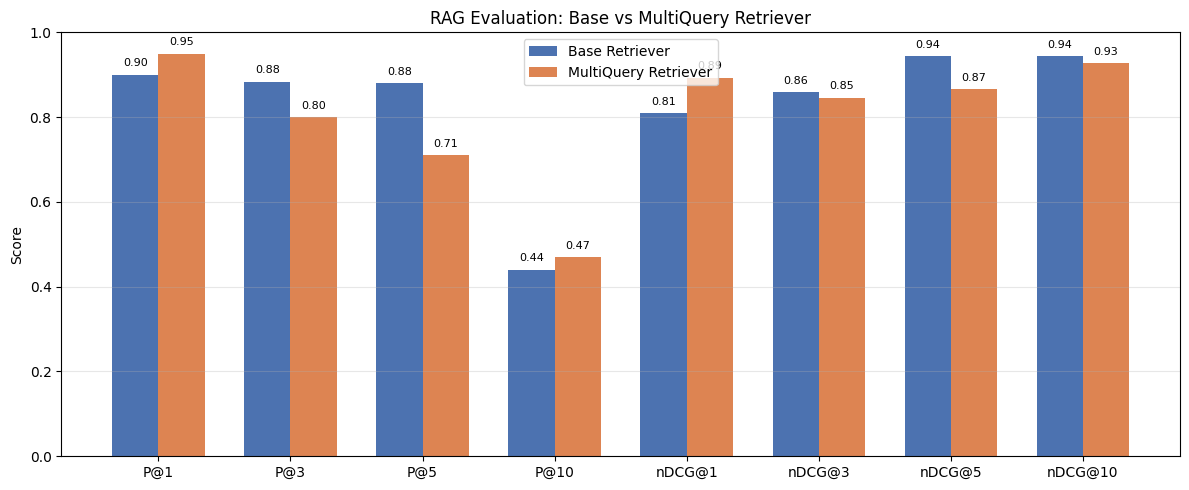

In [9]:
import matplotlib.pyplot as plt
import numpy as np

base_avg = average_metrics(base_results)
multi_avg = average_metrics(multi_results)

metrics = [f"P@{k}" for k in K_VALUES] + [f"nDCG@{k}" for k in K_VALUES]
base_vals = [base_avg[m] for m in metrics]
multi_vals = [multi_avg[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, base_vals, width, label="Base Retriever", color="#4C72B0")
ax.bar(x + width / 2, multi_vals, width, label="MultiQuery Retriever", color="#DD8452")

ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("RAG Evaluation: Base vs MultiQuery Retriever")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (b, m) in enumerate(zip(base_vals, multi_vals)):
    ax.text(i - width / 2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + width / 2, m + 0.02, f"{m:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("eval/results_chart.png", dpi=150)
plt.show()

Per-query breakdown (debug query nào kém)

In [ ]:
import pandas as pd

df_base = pd.DataFrame(base_results).set_index("query")
df_multi = pd.DataFrame(multi_results).set_index("query")

# Hiển thị những query có nDCG@5 thấp nhất để debug
worst_queries = df_base["nDCG@5"].nsmallest(5)
print("⚠️  5 queries có nDCG@5 thấp nhất (Base Retriever):")
print(worst_queries)